# Home Credit Default Risk

**Задача:** предсказать вероятность того, что клиент столкнётся с трудностями при погашении кредита.

Это задача бинарной классификации:

- `TARGET = 0` — клиент погашает кредит без серьёзных проблем;
- `TARGET = 1` — у клиента возникают трудности с выплатами.

Основная метрика проекта — **ROC AUC**, поскольку целевая переменная несбалансирована, а нас интересует качество ранжирования клиентов по уровню риска.

### Что демонстрирует проект

1. Постановку ML-задачи.
2. Exploratory Data Analysis (EDA).
3. Анализ пропусков, распределений и аномалий.
4. Feature engineering на основе бизнес-логики.
5. Logistic Regression как простой baseline.
6. CatBoost как основную модель для табличных данных.
7. Stratified 5-fold cross-validation.
8. Подбор гиперпараметров с Optuna.
9. Проверку моделей на отдельной hold-out validation выборке.
10. Feature importance и SHAP-интерпретацию.
11. Формирование Kaggle submission.

## 1. Почему CatBoost

В данных много числовых и категориальных признаков, есть пропуски и потенциально нелинейные зависимости. Поэтому CatBoost здесь удобен как основная модель: категориальные признаки можно передавать без one-hot encoding, а числовые `NaN` не требуют отдельной импутации.

Logistic Regression при этом станет baseline: так проще оценить, насколько усложнение модели действительно даёт прирост.

## 2. Импорты и настройки

Базовый стек проекта: `pandas` / `numpy` для данных, `matplotlib` / `seaborn` для EDA, `scikit-learn` для baseline и валидации, `CatBoost` и `Optuna` для основной части экспериментов.

In [2]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

import optuna

from catboost import CatBoostClassifier, Pool

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

DATA_DIR = Path("./data")

RANDOM_STATE = 21

## 3. Загрузка данных

`application_train.csv` содержит `TARGET`, а в `application_test.csv` целевой переменной нет — для этих клиентов в конце нужно получить вероятность класса 1.


In [2]:
app_train_raw = pd.read_csv(DATA_DIR / "application_train.csv")
app_test_raw = pd.read_csv(DATA_DIR / "application_test.csv")

print("Train shape:", app_train_raw.shape)
print("Test shape: ", app_test_raw.shape)

display(app_train_raw.head())

Train shape: (307511, 122)
Test shape:  (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 4. Первичный EDA

,count,share
TARGET,,
0,282686,0.919271
1,24825,0.080729


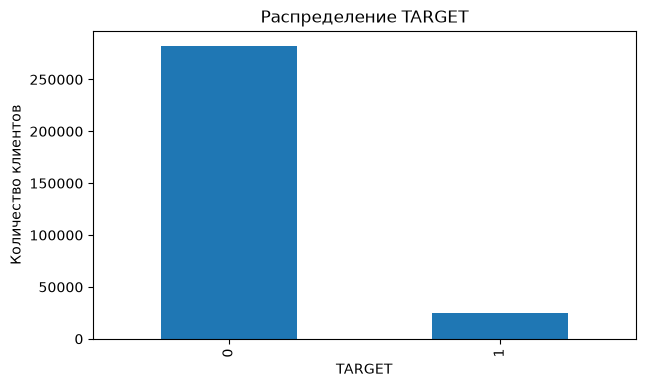

Доля TARGET=1: 0.0807


In [3]:
target_summary = pd.DataFrame({
    "count": app_train_raw["TARGET"].value_counts().sort_index(),
    "share": app_train_raw["TARGET"].value_counts(normalize=True).sort_index(),
})

display(target_summary)

ax = app_train_raw["TARGET"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4),
    title="Распределение TARGET",
)

ax.set_xlabel("TARGET")
ax.set_ylabel("Количество клиентов")
plt.show()

print("Доля TARGET=1:", round(app_train_raw["TARGET"].mean(), 4))

Положительный класс занимает примерно **8%** выборки. Поэтому accuracy без контекста здесь легко переоценить: модель, которая почти всегда выбирает класс 0, уже получит высокую долю правильных ответов.


## 5. Пропуски

In [4]:
def missing_values_table(df):
    missing_count = df.isna().sum()
    missing_percent = 100 * missing_count / len(df)

    table = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent,
    })

    return (
        table[table["missing_count"] > 0]
        .sort_values("missing_percent", ascending=False)
    )

missing_values = missing_values_table(app_train_raw)

print("Столбцов с пропусками:", len(missing_values))
display(missing_values.head(20))

Столбцов с пропусками: 67


,missing_count,missing_percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


Пропуски есть в 67 признаках, а у части жилищных характеристик их доля близка к 70%. Автоматически удалять такие колонки не стоит, сам факт отсутствия информации может быть полезен модели

## 6. Категориальные признаки

In [5]:
categorical_cols_raw = app_train_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Категориальных признаков:", len(categorical_cols_raw))

categorical_cardinality = (
    app_train_raw[categorical_cols_raw]
    .nunique(dropna=False)
    .sort_values()
)

display(categorical_cardinality)

Категориальных признаков: 16


NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
HOUSETYPE_MODE                 4
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
WEEKDAY_APPR_PROCESS_START     7
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
OCCUPATION_TYPE               19
ORGANIZATION_TYPE             58
dtype: int64

## 7. Аномалия DAYS_EMPLOYED

В Home Credit значение 365243 используется как специальный маркер.

Это не настоящий стаж примерно в 1000 лет.

Поэтому:

1. создаём отдельный бинарный признак DAYS_EMPLOYED_ANOM;
2. заменяем 365243 на NaN.

Так модель видит сам факт аномалии, но не воспринимает огромное число как реальный стаж.

In [6]:
ANOMALOUS_EMPLOYED_VALUE = 365243

def clean_employment_anomaly(df):
    df = df.copy()

    df["DAYS_EMPLOYED_ANOM"] = (
        df["DAYS_EMPLOYED"] == ANOMALOUS_EMPLOYED_VALUE
    ).astype("int8")

    df.loc[
        df["DAYS_EMPLOYED"] == ANOMALOUS_EMPLOYED_VALUE,
        "DAYS_EMPLOYED"
    ] = np.nan

    return df

app_train = clean_employment_anomaly(app_train_raw)
app_test = clean_employment_anomaly(app_test_raw)

print(
    "Доля аномального DAYS_EMPLOYED:",
    round(app_train["DAYS_EMPLOYED_ANOM"].mean(), 4),
)

Доля аномального DAYS_EMPLOYED: 0.1801


Маркер `365243` встречается примерно у **18%** клиентов

## 8. Корреляции с TARGET

In [7]:
numeric_corrs = (
    app_train
    .select_dtypes(include=np.number)
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values()
)

print("Наиболее отрицательные корреляции:")
display(numeric_corrs.head(10).to_frame("corr_with_target"))

print("Наиболее положительные корреляции:")
display(numeric_corrs.tail(10).to_frame("corr_with_target"))

Наиболее отрицательные корреляции:


,corr_with_target
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_EMPLOYED_ANOM,-0.045987
FLOORSMAX_AVG,-0.044003
FLOORSMAX_MEDI,-0.043768
FLOORSMAX_MODE,-0.043226
AMT_GOODS_PRICE,-0.039645
REGION_POPULATION_RELATIVE,-0.037227
ELEVATORS_AVG,-0.034199


Наиболее положительные корреляции:


,corr_with_target
FLAG_DOCUMENT_3,0.044346
REG_CITY_NOT_LIVE_CITY,0.044395
FLAG_EMP_PHONE,0.045982
REG_CITY_NOT_WORK_CITY,0.050994
DAYS_ID_PUBLISH,0.051457
DAYS_LAST_PHONE_CHANGE,0.055218
REGION_RATING_CLIENT,0.058899
REGION_RATING_CLIENT_W_CITY,0.060893
DAYS_EMPLOYED,0.074958
DAYS_BIRTH,0.078239


Самые заметные линейные связи с `TARGET` дают `EXT_SOURCE_1/2/3` (примерно от −0.15 до −0.18). У остальных признаков корреляции заметно слабее, поэтому дальше важнее смотреть на нелинейную модель

## 9. Возраст клиента

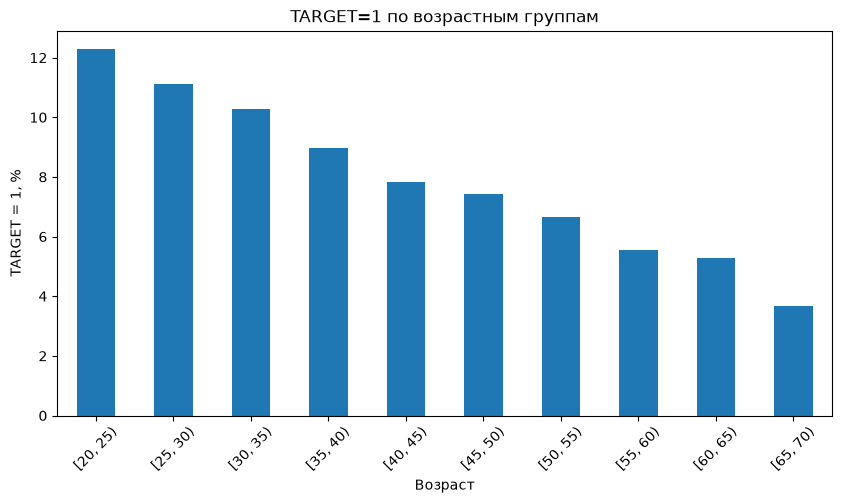

In [8]:
age_data = app_train[["TARGET", "DAYS_BIRTH"]].copy()
age_data["YEARS_BIRTH"] = -age_data["DAYS_BIRTH"] / 365.25

age_data["AGE_BIN"] = pd.cut(
    age_data["YEARS_BIRTH"],
    bins=np.arange(20, 75, 5),
    right=False,
)

age_groups = (
    age_data
    .groupby("AGE_BIN", observed=False)["TARGET"]
    .mean()
    .mul(100)
)

ax = age_groups.plot(
    kind="bar",
    figsize=(10, 5),
    title="TARGET=1 по возрастным группам",
)

ax.set_xlabel("Возраст")
ax.set_ylabel("TARGET = 1, %")
plt.xticks(rotation=45)
plt.show()

## 10. Признак EXT_SOURCE_*

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,1.000000,-0.155317,-0.160472,-0.178919
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000


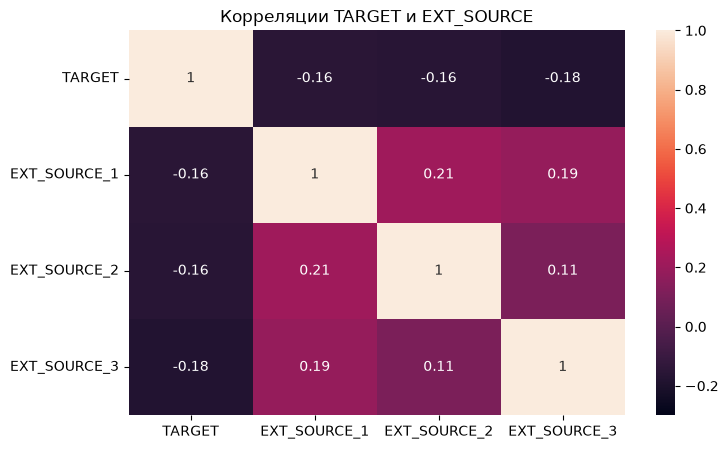

In [9]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

ext_corr = app_train[["TARGET", *ext_cols]].corr(numeric_only=True)
display(ext_corr)

plt.figure(figsize=(8, 5))
sns.heatmap(ext_corr, annot=True, vmin=-0.3, vmax=1.0)
plt.title("Корреляции TARGET и EXT_SOURCE")
plt.show()

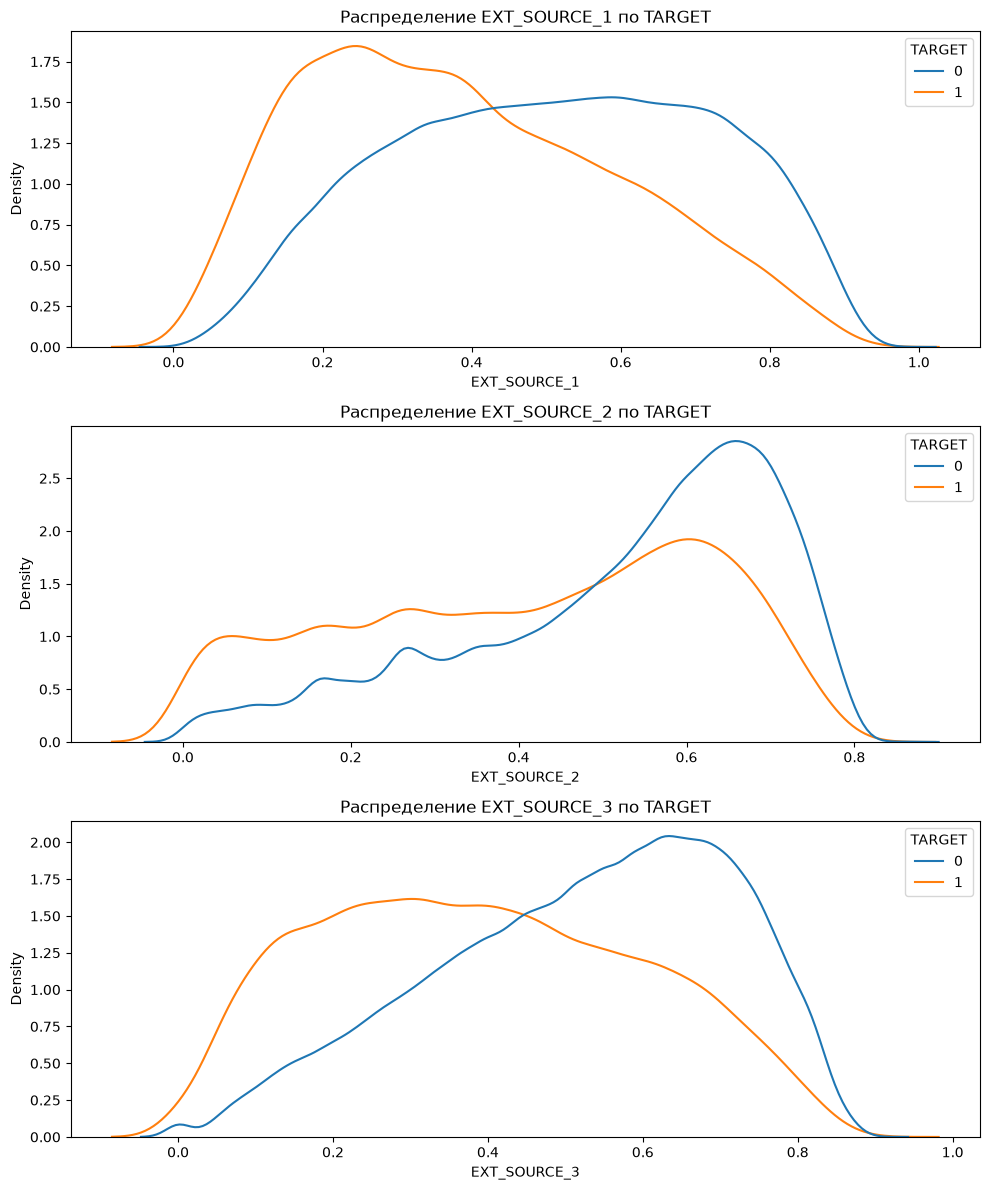

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for ax, col in zip(axes, ext_cols):
    sns.kdeplot(
        data=app_train,
        x=col,
        hue="TARGET",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"Распределение {col} по TARGET")

plt.tight_layout()
plt.show()

## 11. Распределения и выбросы

Для `AMT_INCOME_TOTAL`, `AMT_CREDIT` и `AMT_ANNUITY` рассматривается форма распределений и долю наблюдений за границами IQR.

99-й перцентиль ограничивается **только на графиках** — данные для обучения не обрезаются.

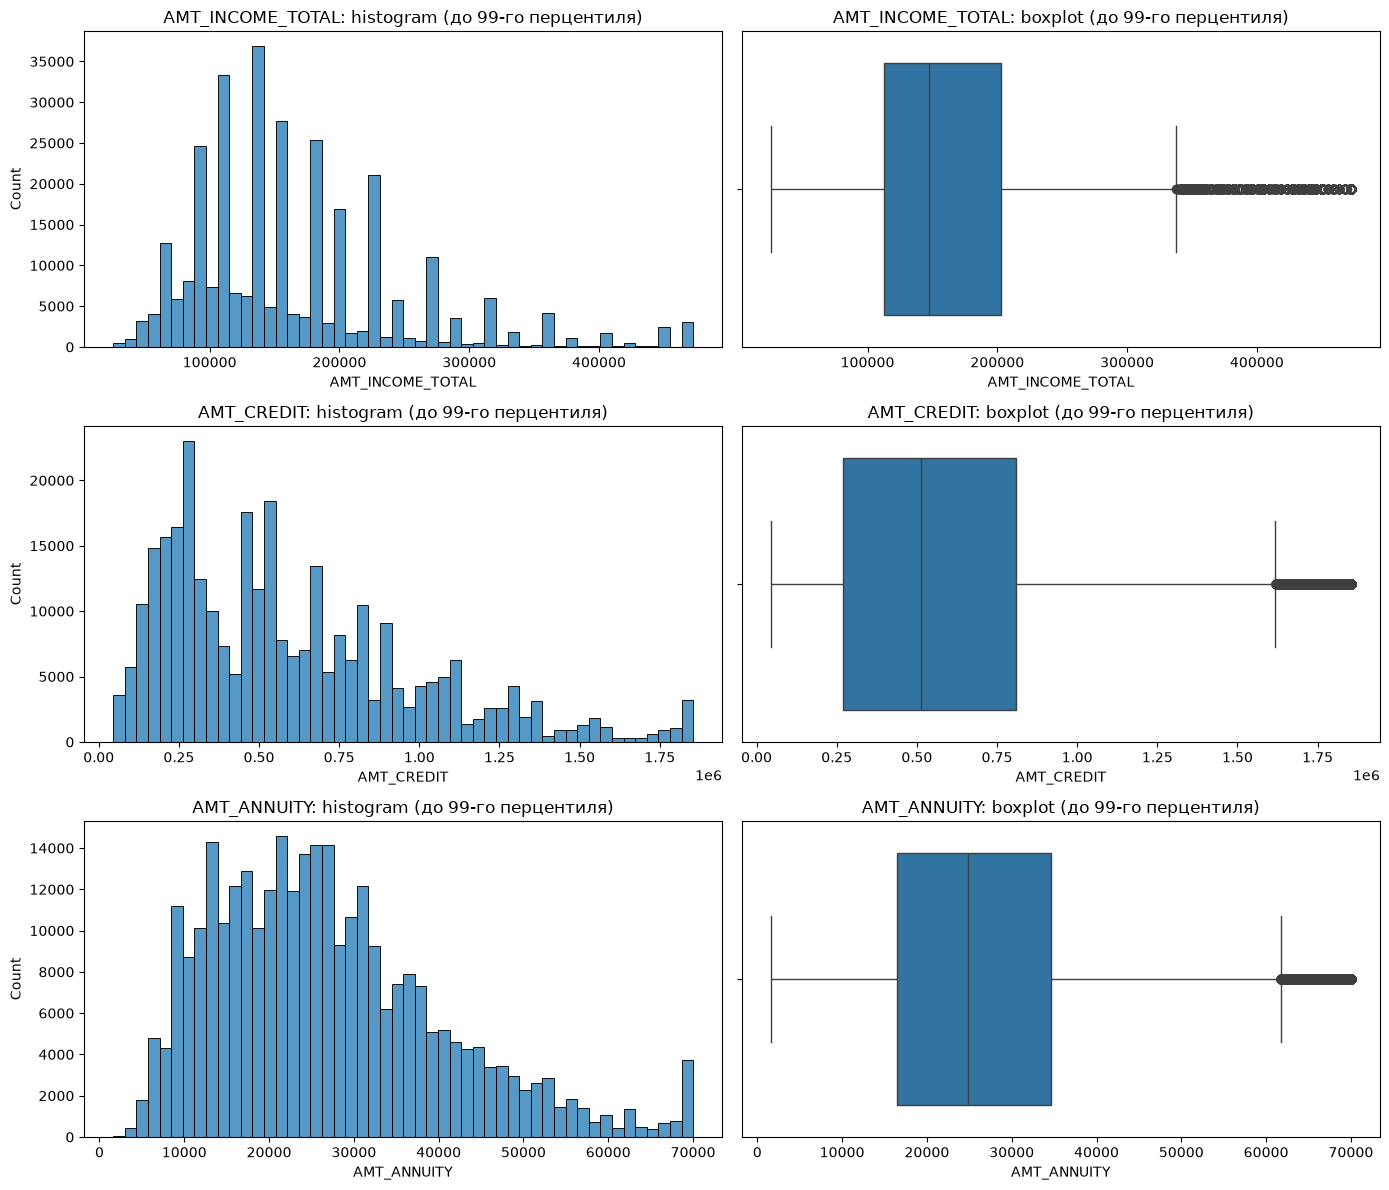

,feature,outlier_count,outlier_percent
0,AMT_INCOME_TOTAL,14035,4.564064
2,AMT_ANNUITY,7504,2.440333
1,AMT_CREDIT,6562,2.133907


In [11]:
plot_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
]

outlier_rows = []

fig, axes = plt.subplots(
    len(plot_cols),
    2,
    figsize=(14, 12),
)

for row, col in enumerate(plot_cols):
    values = app_train[col].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (values < lower_bound)
        | (values > upper_bound)
    )

    outlier_rows.append({
        "feature": col,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_percent": 100 * outlier_mask.mean(),
    })

    # Ограничение используется только для визуализации.
    visual_upper = values.quantile(0.99)
    values_for_plot = values.clip(
        upper=visual_upper
    )

    sns.histplot(
        values_for_plot,
        bins=50,
        ax=axes[row, 0],
    )

    axes[row, 0].set_title(
        f"{col}: histogram (до 99-го перцентиля)"
    )

    sns.boxplot(
        x=values_for_plot,
        ax=axes[row, 1],
    )

    axes[row, 1].set_title(
        f"{col}: boxplot (до 99-го перцентиля)"
    )

plt.tight_layout()
plt.show()

outlier_summary = pd.DataFrame(
    outlier_rows
).sort_values(
    "outlier_percent",
    ascending=False,
)

display(outlier_summary)

## 12. Feature engineering

In [12]:
def add_domain_features(df):
    df = df.copy()

    df["CREDIT_INCOME_PERCENT"] = (
        df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    )

    df["ANNUITY_INCOME_PERCENT"] = (
        df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    )

    df["CREDIT_TERM"] = (
        df["AMT_ANNUITY"] / df["AMT_CREDIT"]
    )

    df["DAYS_EMPLOYED_PERCENT"] = (
        df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
    )

    df["INCOME_PER_PERSON"] = (
        df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
    )

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df

app_train_fe = add_domain_features(app_train)
app_test_fe = add_domain_features(app_test)

engineered_cols = [
    "CREDIT_INCOME_PERCENT",
    "ANNUITY_INCOME_PERCENT",
    "CREDIT_TERM",
    "DAYS_EMPLOYED_PERCENT",
    "INCOME_PER_PERSON",
]

display(
    app_train_fe[["TARGET", *engineered_cols]]
    .corr(numeric_only=True)["TARGET"]
    .sort_values()
    .to_frame("corr_with_target")
)

,corr_with_target
DAYS_EMPLOYED_PERCENT,-0.067955
CREDIT_INCOME_PERCENT,-0.007727
INCOME_PER_PERSON,-0.006571
CREDIT_TERM,0.012704
ANNUITY_INCOME_PERCENT,0.014265
TARGET,1.000000


Из добавленных отношений сильнее остальных выделяется `DAYS_EMPLOYED_PERCENT` (корреляция около −0.068). Остальные ratio-признаки почти не имеют линейной связи с таргетом

## 13. Development / hold-out split

После подготовительных преобразований откладываются 20% размеченных данных в hold-out validation. В Optuna и cross-validation эта часть не участвует; она нужна для сравнения уже обученных кандидатов на одной и той же выборке.

In [13]:
train_ids = app_train_fe["SK_ID_CURR"].copy()
test_ids = app_test_fe["SK_ID_CURR"].copy()

X = app_train_fe.drop(
    columns=["TARGET", "SK_ID_CURR"]
).copy()

X_test = app_test_fe.drop(
    columns=["SK_ID_CURR"]
).copy()

y = app_train_fe["TARGET"].copy()

# Категориальные признаки для CatBoost
cat_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# CatBoost не принимает NaN в категориальных колонках
for col in cat_features:
    X[col] = X[col].fillna("__MISSING__").astype(str)
    X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

# Бесконечности превращаем в NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_dev, X_final_valid, y_dev, y_final_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Development train:", X_dev.shape)
print("Final validation:", X_final_valid.shape)
print("Kaggle test:", X_test.shape)

print(
    "TARGET=1:",
    f"dev={y_dev.mean():.4f}",
    f"final_valid={y_final_valid.mean():.4f}",
)

Development train: (246008, 126)
Final validation: (61503, 126)
Kaggle test: (48744, 126)
TARGET=1: dev=0.0807 final_valid=0.0807


# Baseline Logistic Regression

In [14]:
baseline_train = X_dev.copy()

numeric_cols = baseline_train.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

categorical_cols = baseline_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="__MISSING__",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ]
)

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_cols,
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_cols,
        ),
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocess",
            baseline_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                C=0.01,
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## 14. Logistic Regression 5-fold CV

Baseline оценивается на development-части через stratified 5-fold cross-validation. Оценивается не только средний ROC AUC, но и разброс по фолдам — это помогает понять стабильность оценки.

In [15]:
baseline_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

logistic_cv_scores = cross_val_score(
    logistic_pipeline,
    X_dev,
    y_dev,
    cv=baseline_cv,
    scoring="roc_auc",
    n_jobs=1,
)

logistic_auc = logistic_cv_scores.mean()

print("ROC AUC по фолдам:")
print(np.round(logistic_cv_scores, 5))

print(
    f"\nLogistic Regression CV ROC AUC: "
    f"{logistic_auc:.5f}"
)

ROC AUC по фолдам:
[0.74453 0.74428 0.74642 0.75035 0.74921]

Logistic Regression CV ROC AUC: 0.74696


# CatBoost

## 15. CatBoost Stratified 5-Fold Cross-Validation

Функция ниже собирает OOF-прогнозы, ROC AUC по каждому фолду, число деревьев до early stopping и усреднённый прогноз для test. Общий OOF ROC AUC используется как основная CV-оценка

In [18]:
def train_catboost_cv(
    X: pd.DataFrame,
    y: pd.Series,
    X_test: pd.DataFrame,
    cat_features: list[str],
    n_splits: int = 5,
):
    folds = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    feature_importance = np.zeros(X.shape[1])

    fold_scores = []
    best_iterations = []

    for fold, (train_idx, valid_idx) in enumerate(
        folds.split(X, y),
        start=1,
    ):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostClassifier(
            iterations=5000,
            learning_rate=0.03,
            depth=7,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE + fold,
            task_type="GPU",
            devices= "0",
            l2_leaf_reg=5,
            random_strength=1,
            verbose=False,
            allow_writing_files=False,
        )

        model.fit(
            X_train,
            y_train,
            cat_features=cat_features,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=False,
        )

        valid_pred = model.predict_proba(
            X_valid
        )[:, 1]

        fold_test_pred = model.predict_proba(
            X_test
        )[:, 1]

        oof_pred[valid_idx] = valid_pred
        test_pred += fold_test_pred / n_splits

        fold_auc = roc_auc_score(
            y_valid,
            valid_pred,
        )

        fold_scores.append(fold_auc)
        best_iterations.append(model.get_best_iteration())

        feature_importance += (
            model.get_feature_importance() / n_splits
        )

        print(
            f"Fold {fold}: "
            f"ROC AUC = {fold_auc:.5f}, "
            f"best_iteration = {model.get_best_iteration()}"
        )

        del model, X_train, X_valid, y_train, y_valid
        gc.collect()

    overall_auc = roc_auc_score(
        y,
        oof_pred,
    )

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": feature_importance,
    }).sort_values(
        "importance",
        ascending=False,
    )

    return {
        "oof_auc": overall_auc,
        "fold_scores": fold_scores,
        "best_iterations": best_iterations,
        "test_pred": test_pred,
        "feature_importance": importance_df,
        "oof_pred": oof_pred,
    }

## 16. Baseline CatBoost

In [19]:
%%time

catboost_results = train_catboost_cv(
    X=X_dev,
    y=y_dev,
    X_test=X_test,
    cat_features=cat_features,
    n_splits=5,
)

catboost_auc = catboost_results["oof_auc"]

print(
    f"\nCatBoost CV ROC AUC: "
    f"{catboost_auc:.5f}"
)

display(
    pd.DataFrame({
        "fold": range(
            1,
            len(catboost_results["fold_scores"]) + 1,
        ),
        "ROC_AUC": catboost_results["fold_scores"],
        "best_iteration": catboost_results["best_iterations"],
    })
)

Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1: ROC AUC = 0.76249, best_iteration = 1943


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2: ROC AUC = 0.76531, best_iteration = 2838


Default metric period is 5 because AUC is/are not implemented for GPU


...

Fold 4: ROC AUC = 0.76804, best_iteration = 1604


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5: ROC AUC = 0.77044, best_iteration = 2222

CatBoost CV ROC AUC: 0.76598


,fold,ROC_AUC,best_iteration
0,1,0.762487,1943
1,2,0.765309,2838
2,3,0.764099,3529
3,4,0.768041,1604
4,5,0.770437,2222


CPU times: user 4min 28s, sys: 2min 57s, total: 7min 25s
Wall time: 5min 23s


## 17. Сравнение baseline-моделей

In [20]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "CatBoost baseline",
    ],
    "CV_ROC_AUC": [
        logistic_auc,
        catboost_auc,
    ],
}).sort_values(
    "CV_ROC_AUC",
    ascending=False,
)

display(model_comparison)

,model,CV_ROC_AUC
1,CatBoost baseline,0.765982
0,Logistic Regression,0.746957


## 18. Hyperparameter tuning Optuna

In [21]:
def objective(trial):

    params = {
        "iterations": 2500,

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.015,
            0.08,
            log=True,
        ),

        "depth": trial.suggest_int(
            "depth",
            5,
            8,
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            15.0,
            log=True,
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            3.0,
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            5.0,
        ),

        "loss_function": "Logloss",
        "eval_metric": "AUC",

        "random_seed": RANDOM_STATE,

        "task_type": "GPU",
        "devices": "0",

        "verbose": False,
        "allow_writing_files": False,
        "thread_count": -1,
        "metric_period": 20,
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    scores = []
    best_iterations = []

    for train_idx, valid_idx in cv.split(
        X_dev,
        y_dev,
    ):

        X_train_fold = X_dev.iloc[train_idx]
        X_valid_fold = X_dev.iloc[valid_idx]

        y_train_fold = y_dev.iloc[train_idx]
        y_valid_fold = y_dev.iloc[valid_idx]

        model = CatBoostClassifier(
            **params
        )

        model.fit(
            X_train_fold,
            y_train_fold,

            cat_features=cat_features,

            eval_set=(
                X_valid_fold,
                y_valid_fold,
            ),

            early_stopping_rounds=150,

            use_best_model=True,

            verbose=False,
        )

        valid_pred = model.predict_proba(
            X_valid_fold
        )[:, 1]

        auc = roc_auc_score(
            y_valid_fold,
            valid_pred,
        )

        scores.append(auc)

        best_iterations.append(
            model.tree_count_
        )

        del model
        gc.collect()

    # Сохраняем среднее оптимальное количество деревьев
    trial.set_user_attr(
        "best_iteration",
        int(np.mean(best_iterations)),
    )

    return np.mean(scores)

### Что именно настраивается

Поиск ограничен несколькими основными параметрами дерева и регуляризации. Каждый вариант Optuna проверяется через 5-fold CV, поэтому даже 10 trials требуют десятков обучений CatBoost.

In [26]:
optuna.logging.set_verbosity(
    optuna.logging.ERROR
)

sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)

optuna_start = time.perf_counter()

study.optimize(
    objective,
    n_trials=3,
)

optuna_tuning_time = (
    time.perf_counter() - optuna_start
)

print(
    f"Best Optuna CV ROC AUC: "
    f"{study.best_value:.5f}"
)

print(
    f"Optuna tuning time: "
    f"{optuna_tuning_time / 60:.1f} min"
)

print("\nBest parameters:")

display(
    pd.DataFrame(
        study.best_params.items(),
        columns=[
            "parameter",
            "value",
        ],
    )
)


Best Optuna CV ROC AUC: 0.76441
Optuna tuning time: 15.0 min

Best parameters:


,parameter,value
0,learning_rate,0.016275
1,depth,6.000000
2,l2_leaf_reg,7.045669
3,random_strength,0.064849
4,bagging_temperature,1.029614


In [27]:
best_params = study.best_params.copy()

best_iterations = study.best_trial.user_attrs[
    "best_iteration"
]

print(
    "Оптимальное количество деревьев:",
    best_iterations,
)

optuna_comparison = pd.DataFrame({
    "model": [
        "CatBoost baseline",
        "CatBoost + Optuna",
    ],
    "CV_ROC_AUC": [
        catboost_auc,
        study.best_value,
    ],
})

display(optuna_comparison)


Оптимальное количество деревьев: 2497


,model,CV_ROC_AUC
0,CatBoost baseline,0.765982
1,CatBoost + Optuna,0.764408


In [28]:
optuna_model = CatBoostClassifier(
    **best_params,

    iterations=best_iterations,

    loss_function="Logloss",
    eval_metric="AUC",

    random_seed=RANDOM_STATE,

    task_type="GPU",
    devices="0",

    metric_period=20,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)

optuna_model_start = time.perf_counter()

optuna_model.fit(
    X_dev,
    y_dev,
    cat_features=cat_features,
    verbose=False,
)

optuna_train_time = (
    time.perf_counter() - optuna_model_start
)


## 19. Hold-out validation: итоговое сравнение

Теперь Logistic Regression, baseline CatBoost и CatBoost после Optuna проверяются на одной hold-out выборке.

Основная метрика ROC AUC. Accuracy и F1 при пороге 0.5 показываются только как дополнительные ориентиры

In [31]:
logreg_start = time.perf_counter()

logistic_pipeline.fit(
    X_dev,
    y_dev,
)

logreg_train_time = (
    time.perf_counter() - logreg_start
)

logreg_valid_proba = logistic_pipeline.predict_proba(
    X_final_valid
)[:, 1]

baseline_iterations = int(
    np.median(
        catboost_results["best_iterations"]
    )
)

baseline_params = {
    "learning_rate": 0.03,
    "depth": 7,
    "l2_leaf_reg": 5,
    "random_strength": 1,
}

baseline_model = CatBoostClassifier(
    **baseline_params,
    iterations=baseline_iterations,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    task_type="GPU",
    devices="0",
    metric_period=20,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)

baseline_start = time.perf_counter()

baseline_model.fit(
    X_dev,
    y_dev,
    cat_features=cat_features,
    verbose=False,
)

baseline_train_time = (
    time.perf_counter() - baseline_start
)

baseline_valid_proba = baseline_model.predict_proba(
    X_final_valid
)[:, 1]

optuna_valid_proba = optuna_model.predict_proba(
    X_final_valid
)[:, 1]

def get_metrics(
    y_true,
    probabilities,
    threshold=0.5,
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    return {
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities,
        ),
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
    }

logreg_metrics = get_metrics(
    y_final_valid,
    logreg_valid_proba,
)

baseline_metrics = get_metrics(
    y_final_valid,
    baseline_valid_proba,
)

optuna_metrics = get_metrics(
    y_final_valid,
    optuna_valid_proba,
)

final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "CV_ROC_AUC": logistic_auc,
        "Validation_ROC_AUC": logreg_metrics["ROC_AUC"],
        "Accuracy": logreg_metrics["Accuracy"],
        "F1": logreg_metrics["F1"],
        "Train_time_sec": logreg_train_time,
    },
    {
        "Model": "CatBoost baseline",
        "CV_ROC_AUC": catboost_auc,
        "Validation_ROC_AUC": baseline_metrics["ROC_AUC"],
        "Accuracy": baseline_metrics["Accuracy"],
        "F1": baseline_metrics["F1"],
        "Train_time_sec": baseline_train_time,
    },
    {
        "Model": "CatBoost + Optuna",
        "CV_ROC_AUC": study.best_value,
        "Validation_ROC_AUC": optuna_metrics["ROC_AUC"],
        "Accuracy": optuna_metrics["Accuracy"],
        "F1": optuna_metrics["F1"],
        "Train_time_sec": optuna_train_time,
    },
]).sort_values(
    "Validation_ROC_AUC",
    ascending=False,
).reset_index(drop=True)

display(
    final_comparison.style.format({
        "CV_ROC_AUC": "{:.5f}",
        "Validation_ROC_AUC": "{:.5f}",
        "Accuracy": "{:.5f}",
        "F1": "{:.5f}",
        "Train_time_sec": "{:.1f}",
    })
)

if (
    baseline_metrics["ROC_AUC"]
    >= optuna_metrics["ROC_AUC"]
):
    selected_model = baseline_model
    selected_model_name = "CatBoost baseline"
    selected_params = baseline_params
    selected_iterations = baseline_iterations

else:
    selected_model = optuna_model
    selected_model_name = "CatBoost + Optuna"
    selected_params = best_params
    selected_iterations = best_iterations

print(
    f"\nSelected CatBoost: "
    f"{selected_model_name}"
)

print(
    "Validation ROC AUC:",
    f"{max(baseline_metrics['ROC_AUC'], optuna_metrics['ROC_AUC']):.5f}",
)


,Model,CV_ROC_AUC,Validation_ROC_AUC,Accuracy,F1,Train_time_sec
0,CatBoost baseline,0.76598,0.76682,0.91992,0.05270,57.7
1,CatBoost + Optuna,0.76441,0.76480,0.91997,0.04538,51.5
2,Logistic Regression,0.74696,0.74969,0.91956,0.02484,10.2



Selected CatBoost: CatBoost baseline
Validation ROC AUC: 0.76682


## 20. Feature Importance

,feature,importance
41,EXT_SOURCE_3,13.615126
40,EXT_SOURCE_2,12.405805
123,CREDIT_TERM,8.127825
39,EXT_SOURCE_1,4.710523
15,DAYS_BIRTH,4.479906
8,AMT_GOODS_PRICE,3.099043
16,DAYS_EMPLOYED,2.953119
18,DAYS_ID_PUBLISH,2.613882
7,AMT_ANNUITY,2.398065
17,DAYS_REGISTRATION,2.258991


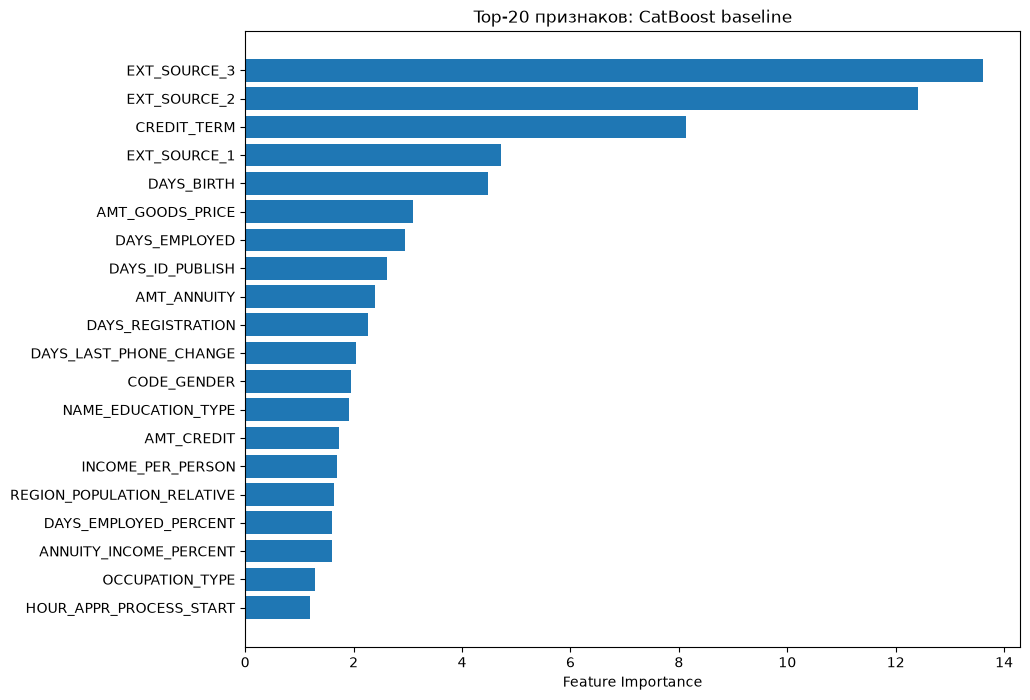

In [32]:
feature_importance = pd.DataFrame({
    "feature": X_dev.columns,

    "importance":
        selected_model.get_feature_importance(),
}).sort_values(
    "importance",
    ascending=False,
)

display(
    feature_importance.head(20)
)

top_features = (
    feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.title(
    f"Top-20 признаков: {selected_model_name}"
)

plt.xlabel(
    "Feature Importance"
)

plt.show()

## 21. SHAP интерпретация модели

SHAP используются в двух режимах: сначала для глобальной важности, затем для разбора отдельного клиента. Это позволяет увидеть не только «что важно», но и какие признаки сдвигают конкретный прогноз вверх или вниз.

In [33]:
SHAP_SAMPLE_SIZE = min(
    3000,
    len(X_final_valid),
)

X_shap = X_final_valid.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

shap_pool = Pool(
    X_shap,
    cat_features=cat_features,
)

shap_values_raw = (
    selected_model.get_feature_importance(
        shap_pool,
        type="ShapValues",
    )
)

shap_values = shap_values_raw[:, :-1]

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,

    "mean_abs_shap":
        np.abs(shap_values).mean(axis=0),
}).sort_values(
    "mean_abs_shap",
    ascending=False,
)

display(
    shap_importance.head(20)
)

,feature,mean_abs_shap
41,EXT_SOURCE_3,0.335340
40,EXT_SOURCE_2,0.323661
8,AMT_GOODS_PRICE,0.211207
39,EXT_SOURCE_1,0.166680
123,CREDIT_TERM,0.150575
7,AMT_ANNUITY,0.113017
1,CODE_GENDER,0.107494
11,NAME_EDUCATION_TYPE,0.100023
15,DAYS_BIRTH,0.089065
6,AMT_CREDIT,0.087973


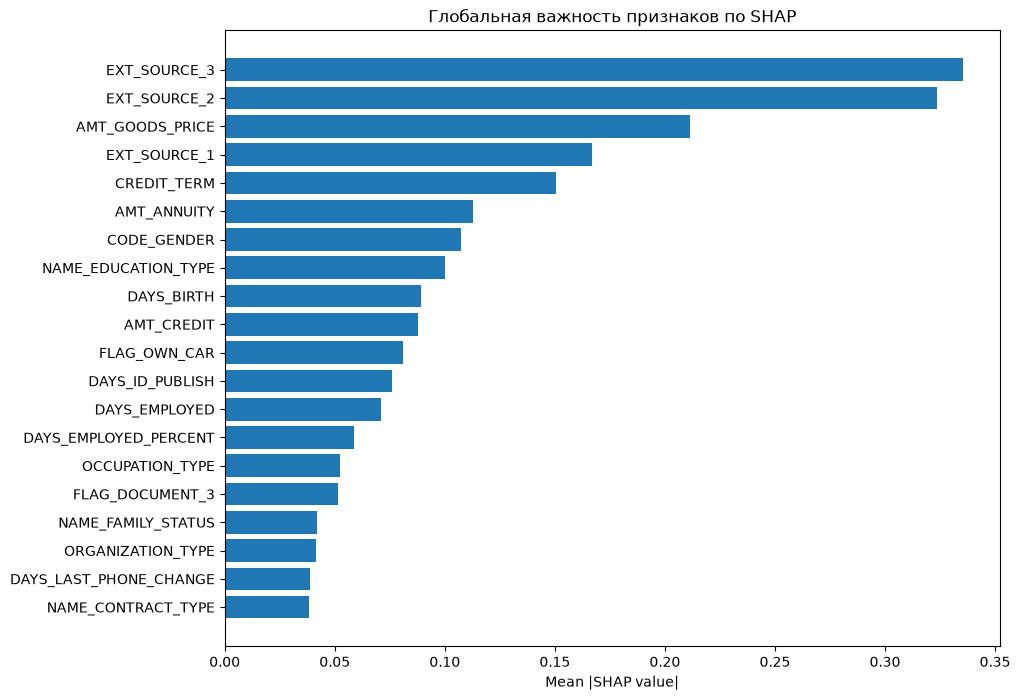

In [34]:
top_shap = (
    shap_importance
    .head(20)
    .sort_values("mean_abs_shap")
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"],
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.title(
    "Глобальная важность признаков по SHAP"
)

plt.show()

### Локальная интерпретация

Глобальная важность отвечает на вопрос «что в среднем влияет на модель». Следующий блок специально переключается на одного клиента с высоким предсказанным риском, чтобы показать, какие признаки сформировали именно его прогноз.


In [35]:
shap_predictions = selected_model.predict_proba(
    X_shap
)[:, 1]

# Выберем клиента с максимальным
# предсказанным риском в SHAP sample
client_position = np.argmax(
    shap_predictions
)

client_probability = (
    shap_predictions[client_position]
)

client_shap = pd.DataFrame({
    "feature": X_shap.columns,

    "value":
        X_shap.iloc[
            client_position
        ].astype(str).values,

    "shap_value":
        shap_values[
            client_position
        ],
})

client_shap["abs_shap"] = (
    client_shap["shap_value"].abs()
)

client_shap = client_shap.sort_values(
    "abs_shap",
    ascending=False,
)

print(
    f"Predicted probability TARGET=1: "
    f"{client_probability:.3f}"
)

display(
    client_shap.head(15)
)

Predicted probability TARGET=1: 0.690


,feature,value,shap_value,abs_shap
41,EXT_SOURCE_3,0.0247439400696317,1.196268,1.196268
40,EXT_SOURCE_2,0.1309621138720706,0.741901,0.741901
123,CREDIT_TERM,0.0794620253164557,0.366097,0.366097
8,AMT_GOODS_PRICE,225000.0,0.296867,0.296867
1,CODE_GENDER,M,0.285964,0.285964
18,DAYS_ID_PUBLISH,-389,0.208529,0.208529
12,NAME_FAMILY_STATUS,Separated,0.135957,0.135957
39,EXT_SOURCE_1,NaN,0.110679,0.110679
16,DAYS_EMPLOYED,-1145.0,0.084614,0.084614
6,AMT_CREDIT,284400.0,-0.074529,0.074529


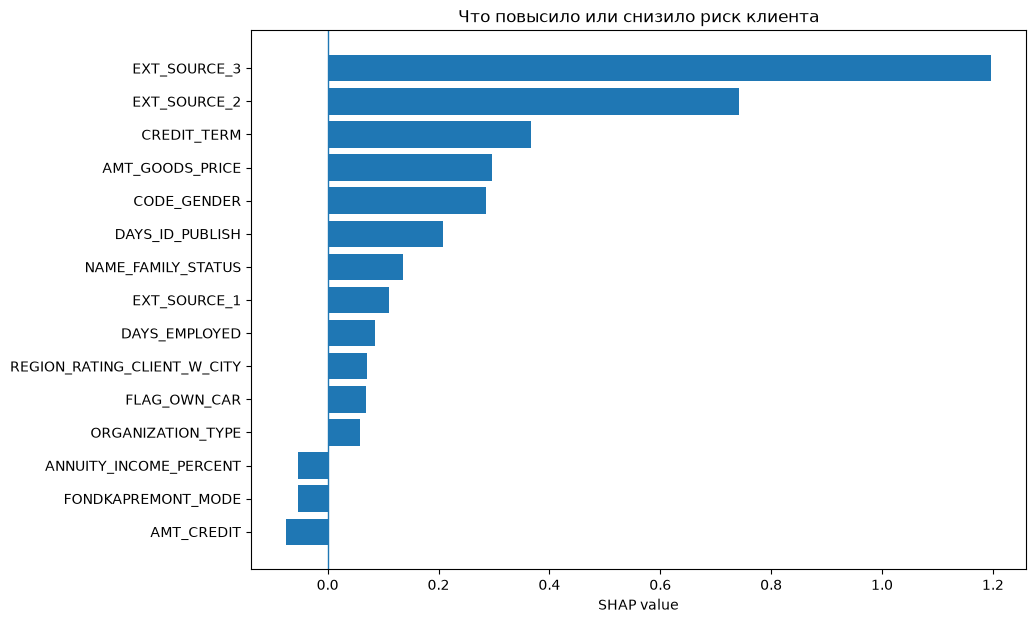

In [36]:
client_top = (
    client_shap
    .head(15)
    .sort_values("shap_value")
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    client_top["feature"],
    client_top["shap_value"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.xlabel(
    "SHAP value"
)

plt.title(
    "Что повысило или снизило риск клиента"
)

plt.show()

### Направление влияния на уровне выборки

In [37]:
top_numeric_features = [
    feature
    for feature in shap_importance["feature"]
    if feature in X_shap.select_dtypes(
        include=np.number
    ).columns
][:10]

business_rows = []

for feature in top_numeric_features:

    feature_idx = X_shap.columns.get_loc(
        feature
    )

    feature_values = X_shap[
        feature
    ]

    feature_shap = shap_values[
        :,
        feature_idx,
    ]

    valid_mask = feature_values.notna()

    value_rank = (
        feature_values[
            valid_mask
        ]
        .rank()
        .to_numpy()
    )

    shap_rank = (
        pd.Series(
            feature_shap[
                valid_mask.to_numpy()
            ]
        )
        .rank()
        .to_numpy()
    )

    if len(value_rank) > 1:

        direction_corr = np.corrcoef(
            value_rank,
            shap_rank,
        )[0, 1]

    else:
        direction_corr = np.nan

    if direction_corr > 0.1:

        interpretation = (
            "Высокие значения чаще повышают "
            "предсказанный риск"
        )

    elif direction_corr < -0.1:

        interpretation = (
            "Высокие значения чаще снижают "
            "предсказанный риск"
        )

    else:

        interpretation = (
            "Связь нелинейная или зависит "
            "от взаимодействий"
        )

    business_rows.append({
        "feature": feature,

        "mean_abs_shap":
            shap_importance.loc[
                shap_importance["feature"]
                == feature,
                "mean_abs_shap",
            ].iloc[0],

        "direction":
            direction_corr,

        "interpretation":
            interpretation,
    })

business_interpretation = pd.DataFrame(
    business_rows
).sort_values(
    "mean_abs_shap",
    ascending=False,
)

display(
    business_interpretation
)

,feature,mean_abs_shap,direction,interpretation
0,EXT_SOURCE_3,0.335340,-0.996343,Высокие значения чаще снижают предсказанный риск
1,EXT_SOURCE_2,0.323661,-0.996641,Высокие значения чаще снижают предсказанный риск
2,AMT_GOODS_PRICE,0.211207,-0.895029,Высокие значения чаще снижают предсказанный риск
3,EXT_SOURCE_1,0.166680,-0.971888,Высокие значения чаще снижают предсказанный риск
4,CREDIT_TERM,0.150575,-0.159939,Высокие значения чаще снижают предсказанный риск
5,AMT_ANNUITY,0.113017,0.940064,Высокие значения чаще повышают предсказанный риск
6,DAYS_BIRTH,0.089065,0.219745,Высокие значения чаще повышают предсказанный риск
7,AMT_CREDIT,0.087973,0.967462,Высокие значения чаще повышают предсказанный риск
8,DAYS_ID_PUBLISH,0.076031,0.964696,Высокие значения чаще повышают предсказанный риск
9,DAYS_EMPLOYED,0.071179,0.841598,Высокие значения чаще повышают предсказанный риск


## 22. Kaggle submission

После выбора конфигурации модель переобучается на всех размеченных данных.

In [ ]:
final_model = CatBoostClassifier(
    **selected_params,

    iterations=selected_iterations,

    loss_function="Logloss",
    eval_metric="AUC",

    task_type="GPU",
    devices="0",

    metric_period=20,

    random_seed=RANDOM_STATE,

    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)

final_model.fit(
    X,
    y,
    cat_features=cat_features,
    verbose=False,
)

test_predictions = final_model.predict_proba(
    X_test
)[:, 1]

submission = pd.DataFrame({
    "SK_ID_CURR": test_ids,
    "TARGET": test_predictions,
})

submission.to_csv(
    "submission_catboost_final.csv",
    index=False,
)

display(
    submission.head()
)

print(
    "Selected configuration:",
    selected_model_name,
)

print(
    "Сохранено: "
    "submission_catboost_final.csv"
)


### Интерпретация результатов

Лучший результат на hold-out validation показал baseline CatBoost с ROC AUC 0.76682, превзойдя Logistic Regression 0.74969 и CatBoost после текущего ограниченного поиска Optuna 0.76480. Это показывает, что нелинейная модель с нативной обработкой категориальных признаков лучше ранжирует клиентов по уровню кредитного риска, чем линейный baseline. При этом проведённый поиск гиперпараметров не дал дополнительного улучшения, поэтому более сложная конфигурация не выбиралась автоматически.

Accuracy для всех моделей находится около 0.92, однако из-за сильного дисбаланса классов эта метрика мало информативна сама по себе. Низкий F1 при стандартном пороге `0.5` также показывает, что порог классификации должен выбираться отдельно с учётом бизнес-стоимости ошибок. Поэтому основной метрикой сравнения моделей остаётся ROC AUC.

SHAP-анализ показывает, что наибольшее глобальное влияние на прогнозы оказывают `EXT_SOURCE_3`, `EXT_SOURCE_2`, `AMT_GOODS_PRICE`, `EXT_SOURCE_1` и созданный признак `CREDIT_TERM`. Особенно важны внешние скоринговые признаки `EXT_SOURCE_*`: более высокие значения этих показателей в выборке в среднем связаны со снижением предсказанного риска дефолта. Это согласуется с тем, что модель рассматривает низкие значения внешних кредитных оценок как один из основных сигналов повышенного риска.

Среди финансовых характеристик заметную роль играют размер кредита, аннуитетный платёж и `CREDIT_TERM`. Для `AMT_CREDIT` и `AMT_ANNUITY` более высокие значения в среднем чаще связаны с увеличением предсказанного риска, тогда как влияние отдельных признаков необходимо рассматривать совместно с остальными характеристиками клиента: SHAP описывает поведение модели, а не причинно-следственные зависимости.

Локальная интерпретация клиента с одним из наиболее высоких прогнозов риска в SHAP-выборке показывает вероятность `TARGET = 1` около 0.690. Наибольший вклад в повышение его модельного риска дают `EXT_SOURCE_3`, `EXT_SOURCE_2` и `CREDIT_TERM`. В частности, очень низкие значения `EXT_SOURCE_3` и `EXT_SOURCE_2` сильно сдвигают прогноз в сторону более высокого риска. Некоторые другие признаки, напротив, частично уменьшают итоговый прогноз, поэтому финальная вероятность формируется совокупностью факторов, а не одним признаком.

Таким образом, модель в первую очередь опирается на внешние скоринговые оценки и финансовые характеристики заявки. Полученный ROC AUC показывает, что она достаточно хорошо ранжирует клиентов по относительному риску, однако перед использованием прогнозов как реальных вероятностей дефолта потребовались бы дополнительная калибровка вероятностей и выбор бизнес-порога принятия решения.

# Итоги

В проекте построен последовательный pipeline кредитного скоринга:

1. сформулирована задача бинарной классификации и выбрана основная метрика ROC AUC;
2. проведён EDA: изучены классы, пропуски, категориальные признаки, распределения и выбросы;
3. обработана аномалия `DAYS_EMPLOYED`;
4. отдельно исследованы возраст и `EXT_SOURCE_*`;
5. создано пять новых финансовых ratio-признаков;
6. построена Logistic Regression как линейный baseline;
7. построен baseline CatBoost с нативной обработкой категориальных признаков;
8. обе baseline-модели оценены через stratified 5-fold cross-validation;
9. гиперпараметры CatBoost дополнительно исследованы с помощью Optuna и 5-fold CV;
10. Logistic Regression, baseline CatBoost и CatBoost + Optuna сравнены на одной hold-out validation выборке;
11. tuning не считается улучшением автоматически для дальнейшей работы выбирается вариант CatBoost с лучшим validation ROC AUC;
12. выбранная модель интерпретируется через Feature Importance и SHAP;
13. после завершения экспериментов выбранная конфигурация переобучается на всех размеченных данных и используется для submission.